In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

processed_data = pd.read_csv("processed_data.csv", index_col = 0)
processed_data.head()

,Utility ID,Source Substation ID,Source Substation,Destination Substation ID,Destination Substation,Line Voltage (kV),Line Length (km),Line Capacity (MVA),Line Status,Line Type,...,Destination Short Name,Destination Region,Destination Country,Destination Latitude,Destination Longitude,Destination Voltage (kV),Destination Capacity (MVA),Destination Commissioning Year,Destination Type,Destination Status
Line ID,,,,,,,,,,,,,,,,,,,,,
1,2,1,Achimota Substation,2,Tema Substation,11,25.2,215.0,Active,Underground,...,Tema,Greater Accra,Ghana,5.6596,-0.0226,330,48.5,1997,Transmission,Active
2,2,1,Achimota Substation,3,Mallam Substation,11,11.0,36.4,Active,Overhead,...,Mallam,Greater Accra,Ghana,5.5630,-0.2971,330,25.2,1979,Transmission,Active
3,3,1,Achimota Substation,5,Kaneshie Substation,11,5.9,277.4,Active,Overhead,...,Kaneshie,Greater Accra,Ghana,5.5691,-0.2413,161,146.0,1970,Transmission,Active
4,1,2,Tema Substation,3,Mallam Substation,330,34.4,39.0,Active,Underground,...,Mallam,Greater Accra,Ghana,5.5630,-0.2971,330,25.2,1979,Transmission,Active
5,3,2,Tema Substation,4,Legon Substation,161,19.5,186.5,Active,Underground,...,Legon,Greater Accra,Ghana,5.6401,-0.1799,161,241.9,2009,Transmission,Active


In [2]:
print(processed_data.shape)
processed_data.describe()

(55, 38)


,Utility ID,Source Substation ID,Destination Substation ID,Line Voltage (kV),Line Length (km),Line Capacity (MVA),Source Latitude,Source Longitude,Source Voltage (kV),Source Capacity (MVA),Source Commissioning Year,Destination Latitude,Destination Longitude,Destination Voltage (kV),Destination Capacity (MVA),Destination Commissioning Year
count,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000
mean,2.836364,17.872727,18.745455,141.381818,99.312727,222.400000,6.432615,-0.781216,142.236364,140.454545,1998.927273,6.537782,-0.871047,116.527273,153.950909,1994.636364
std,1.718781,12.060119,11.719275,135.169097,90.275104,109.181765,1.575944,0.973961,130.455891,139.193805,15.183879,1.652086,1.175620,104.745875,128.707370,15.678912
min,1.000000,1.000000,2.000000,11.000000,3.800000,32.900000,4.904800,-2.850000,11.000000,6.400000,1967.000000,4.874700,-4.300000,11.000000,11.200000,1967.000000
25%,2.000000,7.500000,9.500000,22.000000,42.900000,134.550000,5.544600,-1.623000,33.000000,31.300000,1992.000000,5.569100,-1.623000,33.000000,48.500000,1979.000000
50%,3.000000,16.000000,18.000000,69.000000,75.900000,229.900000,6.101700,-0.774900,69.000000,57.900000,2000.000000,6.035000,-0.750000,69.000000,120.200000,1999.000000
75%,3.000000,27.000000,27.000000,330.000000,129.600000,292.100000,6.685600,-0.199600,330.000000,241.900000,2009.500000,6.614400,-0.179900,161.000000,241.900000,2006.000000
max,9.000000,40.000000,43.000000,330.000000,426.000000,506.300000,11.200000,1.220000,330.000000,423.200000,2022.000000,11.200000,2.430000,330.000000,487.600000,2022.000000


### What type of line connection exist in the network

This talks about the physical connection;
 - Underground
 - Overhead
 

In [3]:
processed_data['Line Type'].value_counts()

Line Type
Overhead       40
Underground    15
Name: count, dtype: int64

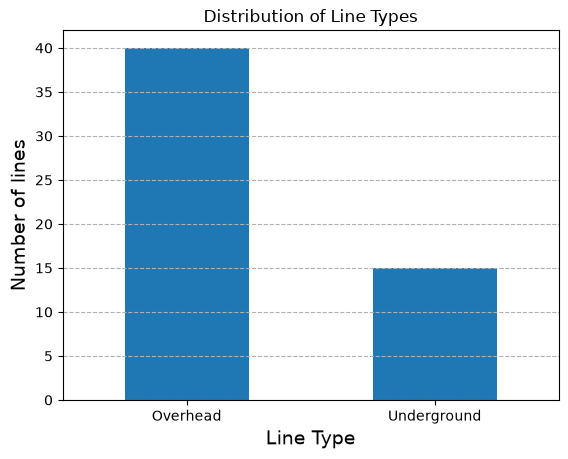

In [4]:
#plt.figure(figsize=(8,6))
processed_data['Line Type'].value_counts().plot(kind = "bar", title = "Distribution of Line Types")

plt.xlabel("Line Type", fontsize= 14)
plt.ylabel("Number of lines", fontsize = 14)
plt.xticks(rotation = 0)
plt.grid(axis="y", linestyle = "--")
plt.show()


### Which electricity company or utility owns the most lines in the network

We have some utilities in the dataset
- GRIDCO
- NEDCO 
- ECG etc

In [5]:
processed_data.columns

Index(['Utility ID', 'Source Substation ID', 'Source Substation',
       'Destination Substation ID', 'Destination Substation',
       'Line Voltage (kV)', 'Line Length (km)', 'Line Capacity (MVA)',
       'Line Status', 'Line Type', 'Utility Name', 'Utility Alias',
       'Utility Code', 'Utility Type', 'Utility Country', 'Active',
       'Source Name', 'Source Short Name', 'Source Region', ' Source Country',
       'Source Latitude', 'Source Longitude', 'Source Voltage (kV)',
       'Source Capacity (MVA)', 'Source Commissioning Year', 'Source Type',
       'Source Status', 'Destination Name', 'Destination Short Name',
       'Destination Region', ' Destination Country', 'Destination Latitude',
       'Destination Longitude', 'Destination Voltage (kV)',
       'Destination Capacity (MVA)', 'Destination Commissioning Year',
       'Destination Type', 'Destination Status'],
      dtype='str')

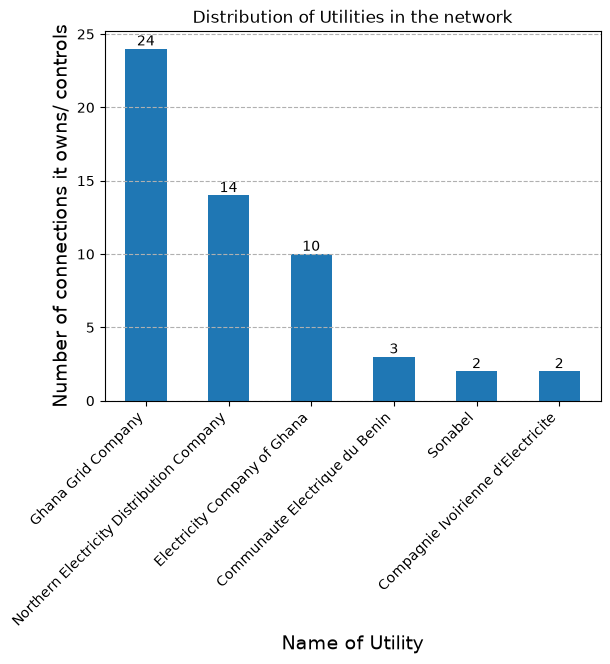

In [6]:

bar_chart = processed_data["Utility Name"].value_counts().plot(kind="bar", title="Distribution of Utilities in the network")

plt.xlabel("Name of Utility", fontsize=14)
plt.ylabel("Number of connections it owns/ controls", fontsize=14)
plt.xticks(rotation= 45, ha = "right")

for container in bar_chart.containers:
    bar_chart.bar_label(container)
    
plt.grid(axis="y", linestyle = "--")
plt.show()


### Which substations are more powerful

In [7]:
from pathlib import Path
import pandas as pd

substations = pd.read_csv("../../data/raw/substations.csv")
substations.head()

,Substation ID,Name,Short Name,Region,Country,Latitude,Longitude,Voltage (kV),Capacity (MVA),Commissioning Year,Type,Status
0,1,Achimota Substation,Achimota,Greater Accra,Ghana,5.6085,-0.2193,11,6.4,2008,Distribution,Active
1,2,Tema Substation,Tema,Greater Accra,Ghana,5.6596,-0.0226,330,48.5,1997,Transmission,Active
2,3,Mallam Substation,Mallam,Greater Accra,Ghana,5.5630,-0.2971,330,25.2,1979,Transmission,Active
3,4,Legon Substation,Legon,Greater Accra,Ghana,5.6401,-0.1799,161,241.9,2009,Transmission,Active
4,5,Kaneshie Substation,Kaneshie,Greater Accra,Ghana,5.5691,-0.2413,161,146.0,1970,Transmission,Active


In [8]:
substations.columns

Index(['Substation ID', 'Name', 'Short Name', 'Region', 'Country', 'Latitude',
       'Longitude', 'Voltage (kV)', 'Capacity (MVA)', 'Commissioning Year',
       'Type', 'Status'],
      dtype='str')

In [9]:
# substations = substations.nlargest(10, "Capacity (MVA)")
# substations[["Name", "Voltage (kV)", "Capacity (MVA)", "Region"]]

# '''
# OR
substations_capacity = substations.sort_values(by="Capacity (MVA)", ascending=False).head(10)
substations_capacity[["Name", "Voltage (kV)", "Capacity (MVA)", "Region"]]

,Name,Voltage (kV),Capacity (MVA),Region
40,Cotonou Transmission Hub,161,487.6,Benin
42,Bobo-Dioulasso Hub,161,445.9,Burkina Faso
38,Aflao Border Station,330,423.2,Togo border
21,Nkawkaw Substation,69,389.2,Eastern
23,Ho Substation,330,382.1,Volta
7,Ejisu Substation,330,355.9,Ashanti
22,Suhum Substation,69,339.0,Eastern
33,Bolgatanga Substation,161,325.9,Upper East
10,Konongo Substation,69,285.2,Ashanti
37,Elubo Border Station,330,285.1,Cote d'Ivoire border


<Figure size 1000x800 with 0 Axes>

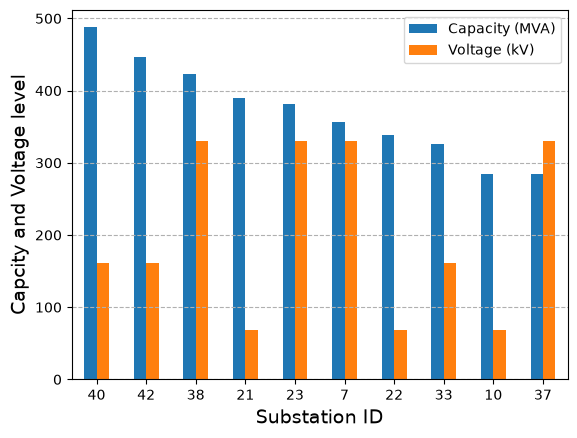

In [10]:
plt.figure(figsize=(10,8))
my_plot = substations_capacity[["Capacity (MVA)", "Voltage (kV)"]].plot(kind="bar")

plt.xlabel("Substation ID", fontsize=14)
plt.ylabel("Capcity and Voltage level", fontsize= 14)
plt.xticks(rotation = 0)

plt.grid(axis="y", linestyle = "--")
plt.show()

In [11]:
substations.groupby("Voltage (kV)")["Capacity (MVA)"].mean().sort_values(ascending=False)

Voltage (kV)
161    250.009091
330    209.960000
69     199.500000
33      34.233333
11      32.777778
Name: Capacity (MVA), dtype: float64

This means voltage alone cannot be used to study or make informed decisions of the substations since
the substations having the highest capacity are not the ones having the largest voltage

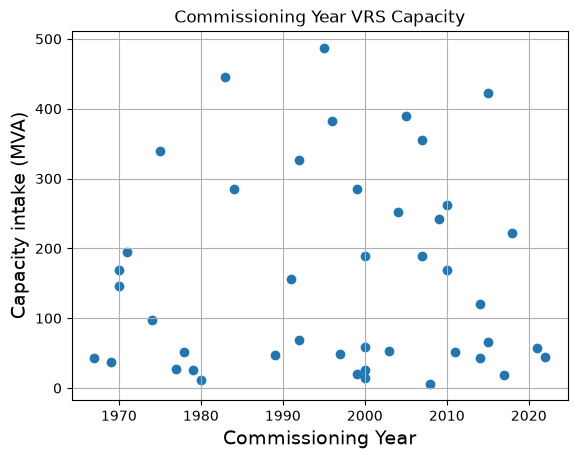

In [12]:

plt.scatter(
    substations['Commissioning Year'], 
    substations["Capacity (MVA)"]
    )
# plt.scatter(
#     substations['Voltage (kV)'], 
#     substations["Capacity (MVA)"]
#     )
plt.title("Commissioning Year VRS Capacity")
plt.xlabel("Commissioning Year", fontsize=14)
plt.ylabel("Capacity intake (MVA)", fontsize=14)

plt.grid(True)
plt.show()



In [13]:
print(substations["Commissioning Year"].corr(substations["Capacity (MVA)"]))
print(substations["Voltage (kV)"].corr(substations["Capacity (MVA)"]))

0.031479703267168424
0.44341681011772244


### What is distribution of voltage levels across the substations
This talks about how many substations belong to each voltage level.
Though we want distribution, but the count of uniques voltage is discrete or small, meaning histogram is not needed rather a bar chat will be best to show under each volatage level, the number of substations having that voltage.


In [14]:

substations["Voltage (kV)"].value_counts()


# value_counts() = sort by data values
# sort_index() = sort by labels 

Voltage (kV)
161    11
330    10
11      9
69      8
33      6
Name: count, dtype: int64

In [15]:
substations["Voltage (kV)"].nunique()

5

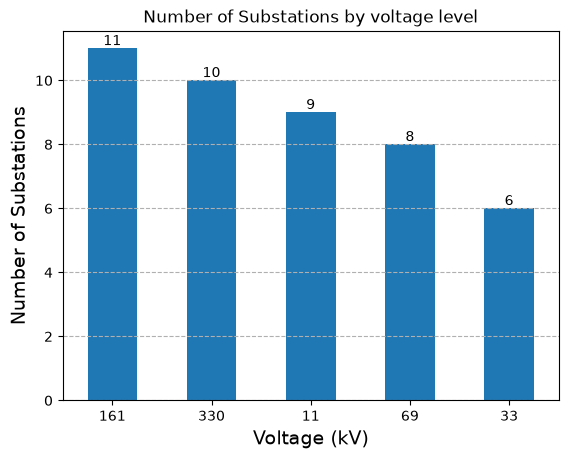

In [16]:
substations = substations["Voltage (kV)"].value_counts()



voltage_counts = substations.plot(kind="bar")
plt.title("Number of Substations by voltage level")

plt.xlabel("Voltage (kV)", fontsize= 14)
plt.ylabel("Number of Substations", fontsize= 14)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--")

for container in voltage_counts.containers:
    voltage_counts.bar_label(container)

plt.show()

The dataset contains more 161 kV substations (11) than any other voltage category, while 33 kV substations are the least represented (6). Although lower-voltage infrastructure are expected to more since they are geographically more widespread closer to consumers but here they are few meaning this dataset may represent selected or major grid substations rather than the complete distribution network.

### What is the age distribution of the substations
This will help me to know if there are many older substations or there are newer substations or there is a gradual development of the substations over years.

In [17]:
from pathlib import Path
import pandas as pd

substations = pd.read_csv("../../data/raw/substations.csv")
substations['Commissioning Year'].nunique()

34

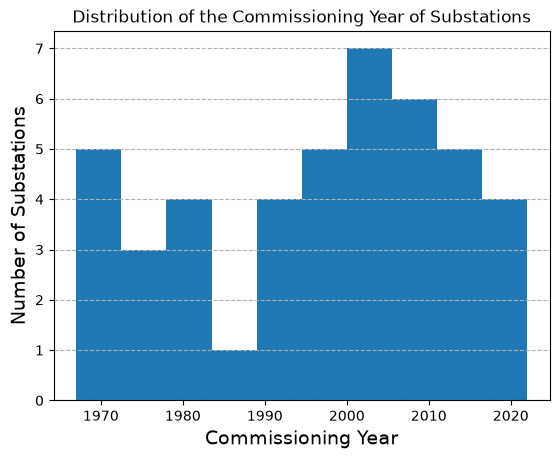

In [18]:
substations_aging = substations["Commissioning Year"].plot(kind="hist")
plt.title("Distribution of the Commissioning Year of Substations")
plt.xlabel('Commissioning Year', fontsize=14)
plt.ylabel("Number of Substations", fontsize= 14)

plt.grid(axis="y", linestyle= "--")
plt.show()


In [19]:
substations['Commissioning Year'].describe()

# Distribution is left or negatively skewed, meaning more of the substations are new or modern a few
# old ones extend the distribution towards the left. Also median > mean 

count      44.000000
mean     1996.295455
std        16.112366
min      1967.000000
25%      1982.250000
50%      1999.500000
75%      2009.250000
max      2022.000000
Name: Commissioning Year, dtype: float64

WHY IT WAS STUDIED

The commissioning year provides an indication of the age of each substation. Older substations may be more susceptible to equipment wear, failures, and higher maintenance requirements. When combined with other variables such as voltage, capacity, and network connectivity, commissioning year can help identify substations that may have a higher risk of failure or require infrastructure upgrades.